# Preview: Dataset505_ARCADE_oversampled

Built by `dataset-prep/prepare_arcade_vessel_coverage.py`, from scratch (not
derived from Dataset502 like Dataset503/504 are). Instead of tiling each
source image into a fixed grid, patches are placed directly on the vessel:

1. Rasterize the binary vessel mask from the ARCADE COCO annotations.
2. Skeletonize it (the whole image's vessel tree, branches included).
3. Farthest-point sampling (FPS) on the skeleton pixels picks 36 well-spread
   centers per image -- each new point is whichever remaining skeleton pixel
   is farthest from every already-picked center, which is a coverage-
   maximizing coarse sliding window along the vessel.
4. Each center becomes one 85x85 patch (clamped to stay inside the image).

Every patch center is itself a vessel pixel, so **every patch contains
vessel by construction** -- no empty-patch filtering step needed, unlike
Dataset503 (downsampled) / Dataset504 (fully filtered) which both start
from Dataset502's grid tiling and have to remove empty patches after the
fact.

No imagesTs/labelsTs here on purpose -- evaluate against
Dataset502_ARCADE_6x6_1c's imagesTs/labelsTs (standard grid tiling, not
vessel-biased) for comparable metrics across experiments.

In [1]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

sys.path.insert(0, str(Path.cwd()))

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "dataset-prep" else Path.cwd()
ROOT = REPO_ROOT / "data" / "nnUNet_raw" / "Dataset505_ARCADE_oversampled"
IMAGES_TR = ROOT / "imagesTr"
LABELS_TR = ROOT / "labelsTr"

rng = random.Random(0)

## Dataset summary

In [2]:
dataset_json = json.loads((ROOT / "dataset.json").read_text())
splits = json.loads((ROOT / "splits_final.json").read_text())

print(json.dumps(dataset_json, indent=2))
print(f"\nfolds: {len(splits)}")
print(f"train patches: {len(splits[0]['train'])}")
print(f"val patches:   {len(splits[0]['val'])}")
print(f"train/val overlap: {len(set(splits[0]['train']) & set(splits[0]['val']))} (should be 0)")

# source-image count implied by the "_v00".._v35" suffix convention
train_images = {c.rsplit("_v", 1)[0] for c in splits[0]["train"]}
val_images = {c.rsplit("_v", 1)[0] for c in splits[0]["val"]}
print(f"\nsource images contributing to train: {len(train_images)}")
print(f"source images contributing to val:   {len(val_images)}")
print(f"avg patches/image (train): {len(splits[0]['train']) / len(train_images):.1f}")

{
  "channel_names": {
    "0": "grayscale"
  },
  "labels": {
    "background": 0,
    "vessel": 1
  },
  "numTraining": 43200,
  "file_ending": ".png",
  "name": "Dataset505_ARCADE_oversampled"
}

folds: 1
train patches: 36000
val patches:   7200
train/val overlap: 0 (should be 0)

source images contributing to train: 1000
source images contributing to val:   200
avg patches/image (train): 36.0


## Vessel-pixel density -- confirms "no empty patches"

Fraction of each patch's pixels that are vessel, over a random sample.
Contrast with a grid-tiled dataset (Dataset502/503/504's source), where most
patches sit at 0% -- that's the whole reason those datasets need an empty-
patch downsampling/filtering step and this one doesn't.

sampled 2000 patches, 0 empty (0% vessel)
density: min=0.018 median=0.151 mean=0.159 max=0.488


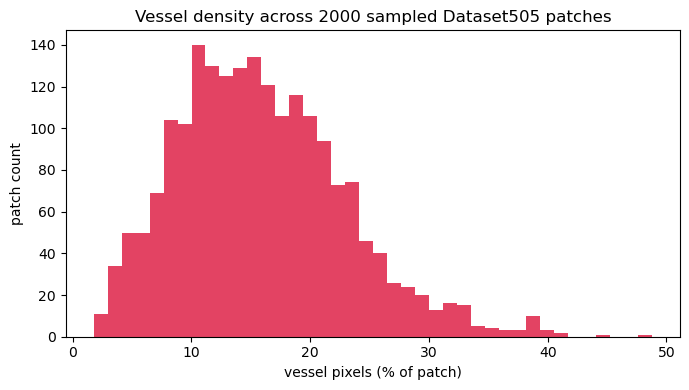

In [3]:
label_files = sorted(LABELS_TR.glob("*.png"))
sample_files = rng.sample(label_files, min(2000, len(label_files)))

densities = []
for f in sample_files:
    arr = np.asarray(Image.open(f))
    if arr.ndim == 3:
        arr = arr[..., 0]
    densities.append((arr == 1).mean())
densities = np.array(densities)

n_empty = int((densities == 0).sum())
print(f"sampled {len(densities)} patches, {n_empty} empty (0% vessel)")
print(f"density: min={densities.min():.3f} median={np.median(densities):.3f} "
      f"mean={densities.mean():.3f} max={densities.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(densities * 100, bins=40, color="crimson", alpha=0.8)
ax.set_xlabel("vessel pixels (% of patch)")
ax.set_ylabel("patch count")
ax.set_title(f"Vessel density across {len(densities)} sampled Dataset505 patches")
plt.tight_layout()
plt.show()

## Sample patches (image / label pairs)

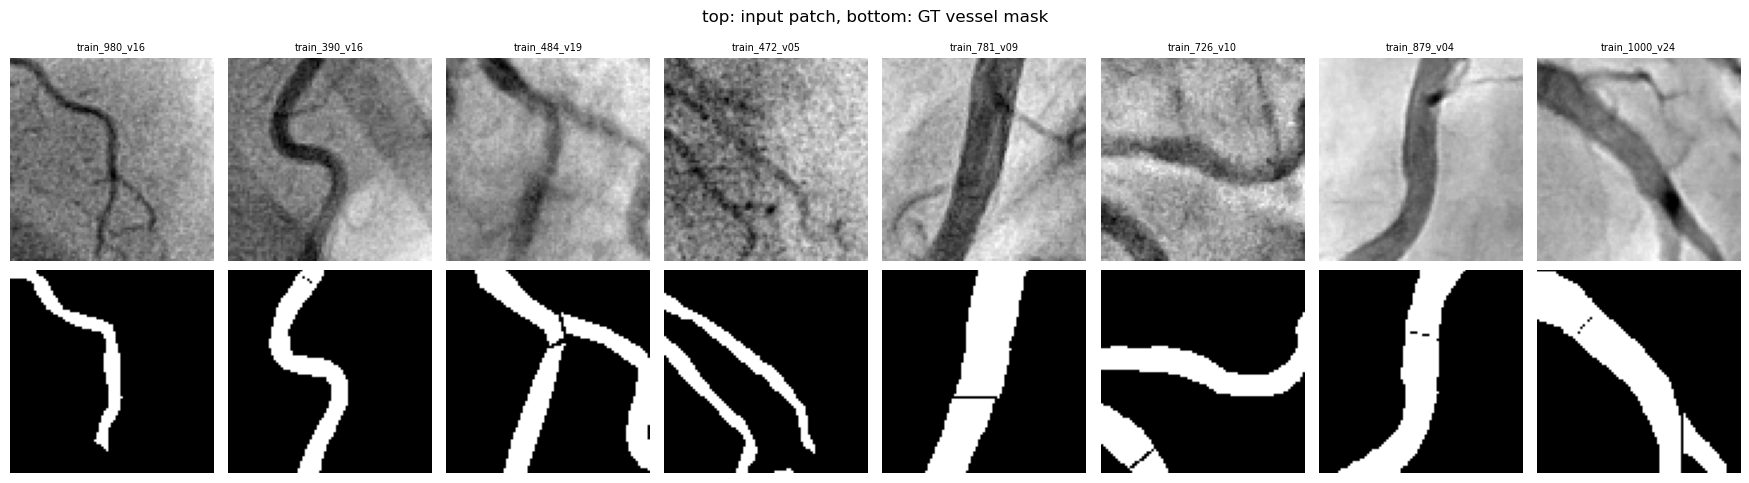

In [4]:
sample_cases = rng.sample([f.stem for f in label_files], 8)

fig, axes = plt.subplots(2, len(sample_cases), figsize=(2.2 * len(sample_cases), 5))
for i, case in enumerate(sample_cases):
    img = Image.open(IMAGES_TR / f"{case}_0000.png")
    lbl = np.asarray(Image.open(LABELS_TR / f"{case}.png"))
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(case, fontsize=7)
    axes[0, i].axis("off")
    axes[1, i].imshow(lbl, cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
fig.suptitle("top: input patch, bottom: GT vessel mask")
plt.tight_layout()
plt.show()

## Per-image coverage -- all 36 patches for a few source images

Reconstructs each source image's full 512x512 frame from its patches'
filename indices isn't possible (patches don't retain absolute source
coordinates once cropped), so instead this re-derives the patch boxes
directly from the original ARCADE annotations using the same function the
build script used, and overlays them -- the same sanity-check plot used to
validate the sampling strategy before running the full build.

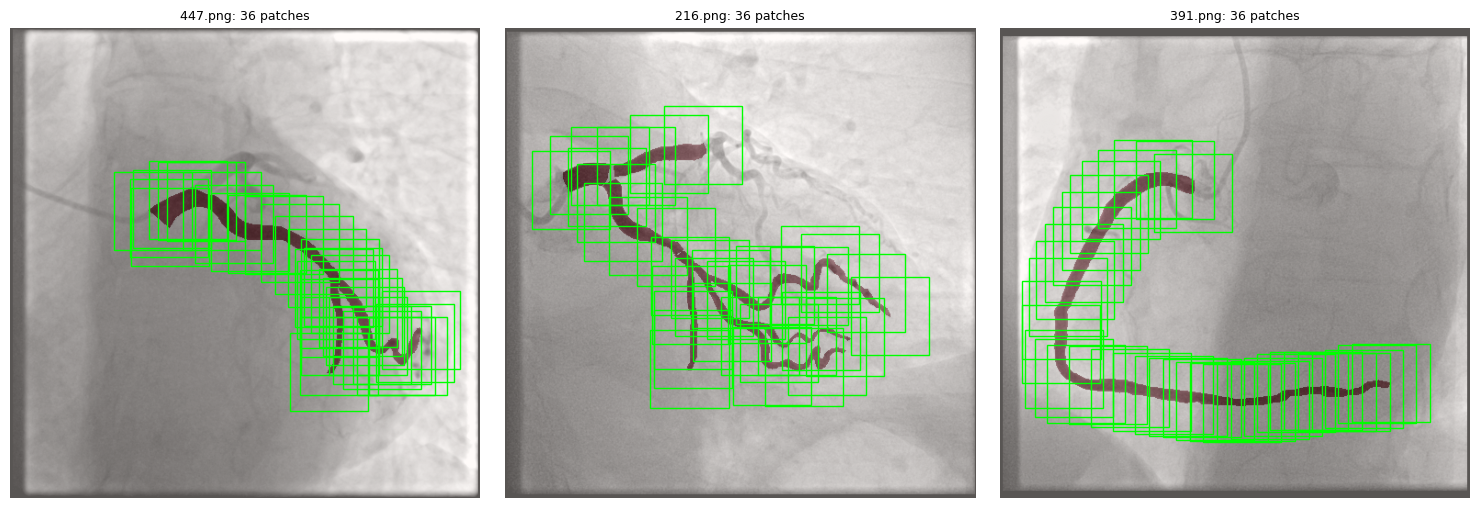

In [5]:
from coco2png import build_annotations_index, build_image_index, load_coco
from prepare_arcade import build_binary_mask, default_supported_classes, to_grayscale
from prepare_arcade_vessel_coverage import PATCH_SIZE, PATCHES_PER_IMAGE, vessel_patch_boxes

source_dir = Path("ARCADE") / "data" / "syntax"
json_path = source_dir / "train" / "annotations" / "train.json"
images_dir = source_dir / "train" / "images"

coco = load_coco(json_path)
image_index = build_image_index(coco.get("images", []))
ann_index = build_annotations_index(coco.get("annotations", []))
ids = default_supported_classes(coco)

sample_keys = rng.sample(sorted(image_index), 3)
fig, axes = plt.subplots(1, len(sample_keys), figsize=(5 * len(sample_keys), 5))
for ax, k in zip(axes, sample_keys):
    img_info = image_index[k]
    with Image.open(images_dir / img_info["file_name"]) as im:
        gray = np.array(to_grayscale(im))
    mask = build_binary_mask(img_info, ann_index, ids)
    boxes = vessel_patch_boxes(mask, PATCH_SIZE, PATCHES_PER_IMAGE)

    ax.imshow(gray, cmap="gray")
    ax.imshow(mask, cmap="Reds", alpha=0.35)
    for (x0, y0, x1, y1) in boxes:
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=1))
    ax.set_title(f"{img_info['file_name']}: {len(boxes)} patches", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()